# 03 — Clustering & PCA Visualisation

**Objective:** Normalise the 10 selected features, determine the
optimal number of clusters via Elbow + Silhouette analysis, fit
K-Means (k=4), assign persona labels based on centroid inspection,
and visualise the segments in PCA-reduced 2-D space.

**Input:** `data/processed/featured_customers.csv`  
**Output:** Updated dataframe with `CLUSTER_ID`, `SEGMENT_NAME`,
`PC1`, `PC2` columns (carried forward to Notebook 04).

In [11]:
import sys
%pip install plotly
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import ensure_directories, FEATURED_CSV_PATH
ensure_directories()


  Using cached plotly-6.7.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached narwhals-2.19.0-py3-none-any.whl.metadata (14 kB)
Using cached plotly-6.7.0-py3-none-any.whl (9.9 MB)
Using cached narwhals-2.19.0-py3-none-any.whl (446 kB)



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\ADMIN\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


## 1. Load Feature-Enriched Data

In [12]:
import pandas as pd

df = pd.read_csv(FEATURED_CSV_PATH, index_col="CUST_ID")
print(f"Loaded featured data: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded featured data: 8949 rows, 23 columns


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,...,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,UTILIZATION_RATIO,PAYMENT_TO_BALANCE,SPEND_VELOCITY,INSTALLMENT_FREQUENCY,CASH_ADVANCE_RATIO,PURCHASE_TYPE_RATIO
CUST_ID,,,,,,,,,,,,,,,,,,,,,
C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,...,201.802084,139.509787,0.000000,12.0,0.040901,4.816193,0.095400,0.989627,0.000000,0.000000
C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,...,4103.032597,1072.340217,0.222222,12.0,0.457495,1.280810,0.000000,0.000000,0.999845,0.000000
C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,...,622.066742,627.284787,0.000000,12.0,0.332687,0.249211,0.103089,0.000000,0.000000,0.998708
C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,...,0.000000,312.343947,0.000000,12.0,0.222223,0.000000,0.199867,0.000000,0.120641,0.999333
C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,...,678.334763,244.791237,0.000000,12.0,0.681429,0.828537,0.013333,0.000000,0.000000,0.941176


## 2. Feature Normalisation (StandardScaler)

K-Means is distance-based and sensitive to feature scales.
We apply `StandardScaler` (zero-mean, unit-variance) to the
10 clustering features. The fitted scaler is persisted with
`joblib` for reuse during anomaly detection.

In [13]:
from src.clustering import normalise_features
from src.utils import CLUSTERING_FEATURES

print(f"Clustering features ({len(CLUSTERING_FEATURES)}):")
for i, feat in enumerate(CLUSTERING_FEATURES, 1):
    print(f"  {i:2d}. {feat}")

scaled_array, scaler = normalise_features(df)

Clustering features (10):
   1. BALANCE
   2. PURCHASES
   3. CASH_ADVANCE
   4. CREDIT_LIMIT
   5. PAYMENTS
   6. UTILIZATION_RATIO
   7. PAYMENT_TO_BALANCE
   8. SPEND_VELOCITY
   9. INSTALLMENT_FREQUENCY
  10. CASH_ADVANCE_RATIO
  ✓ StandardScaler fitted and saved → standard_scaler.joblib


## 3. Optimal k — Elbow + Silhouette Analysis

We test k = 2 to 12 for inertia (WCSS) and k = 2 to 10 for
Silhouette Score. The `kneed` library is used for programmatic
elbow detection; both metrics should converge on **k = 4**.

In [14]:
from src.clustering import plot_elbow_and_silhouette

optimal_k = plot_elbow_and_silhouette(scaled_array)
print(f"\nProceeding with k = {optimal_k}")

  ✓ Elbow + Silhouette plot saved → 06_elbow_silhouette.png
  ✓ Optimal k detected: 4

Proceeding with k = 4


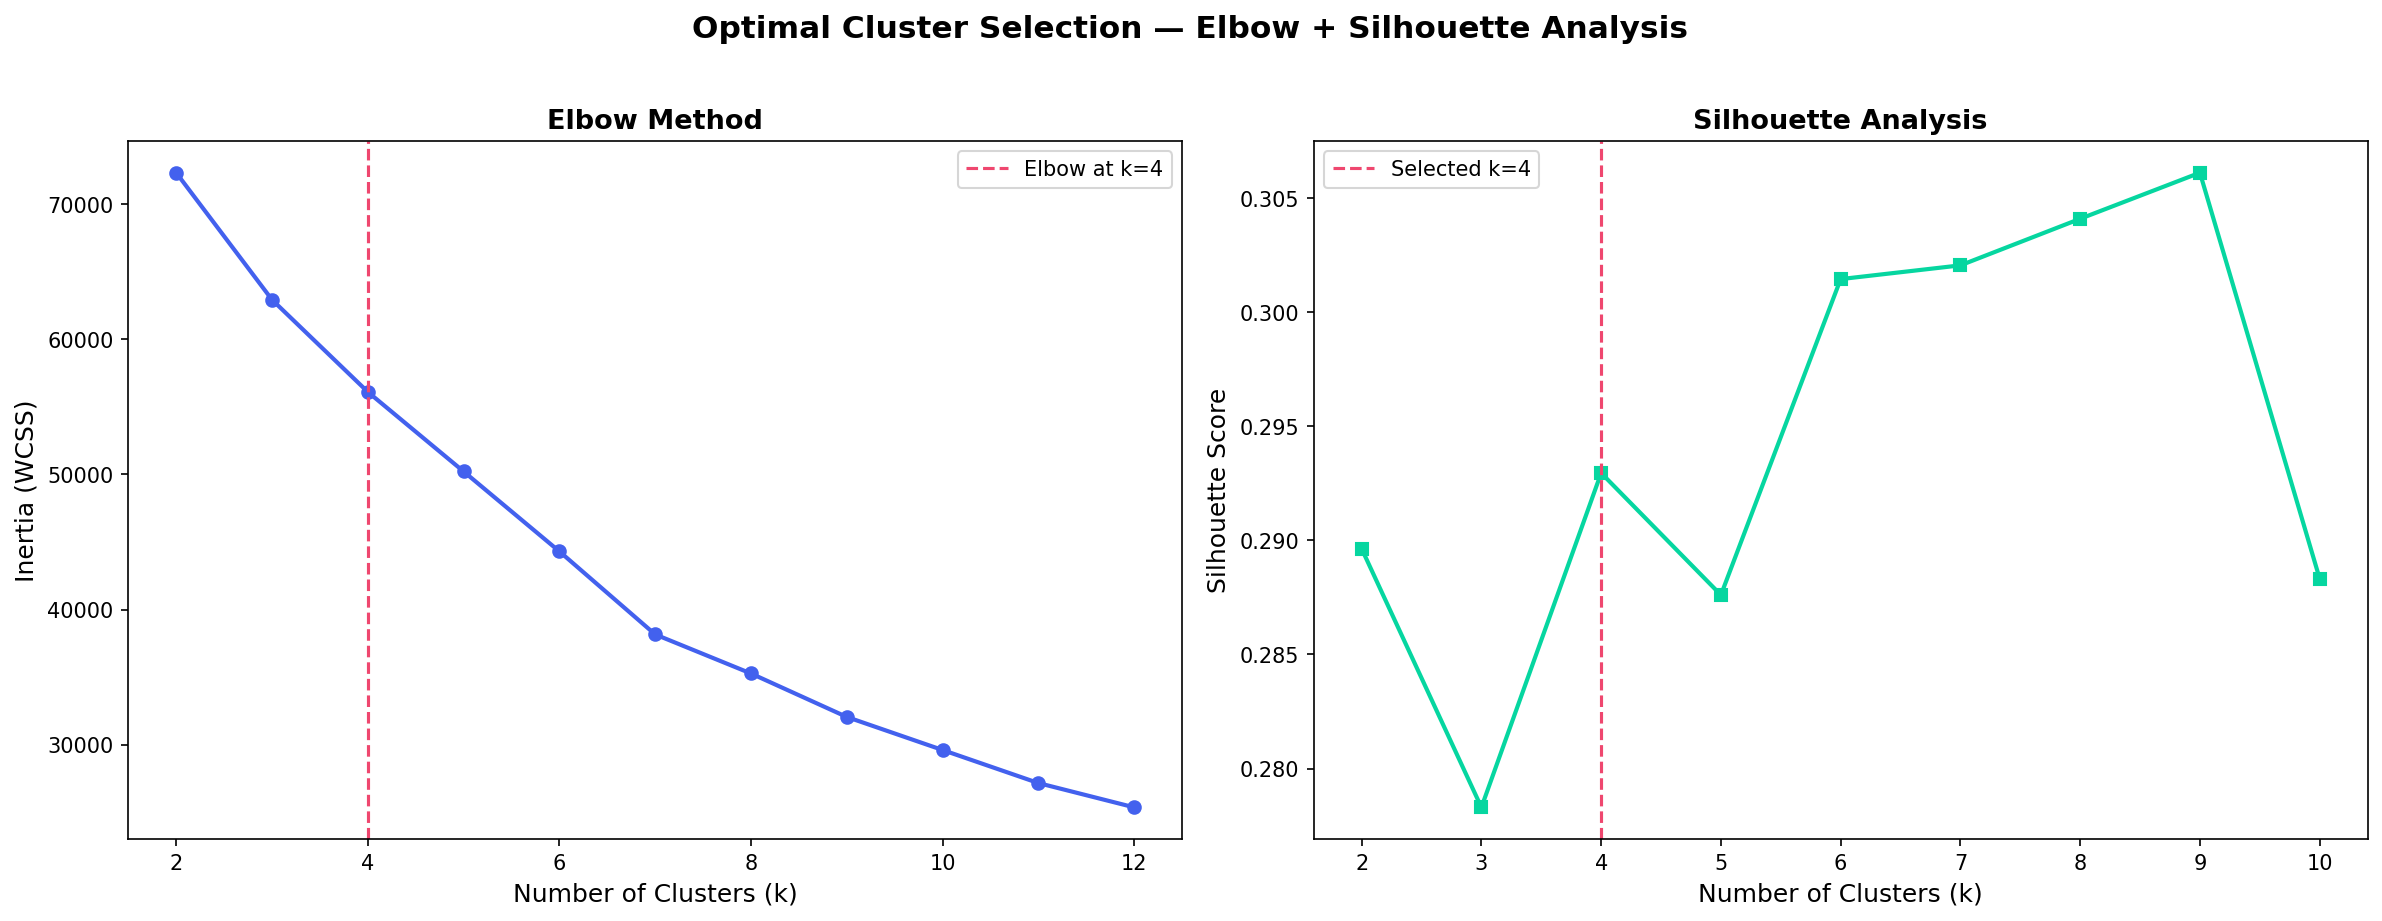

In [15]:
from IPython.display import Image
from src.utils import PLOTS_DIR

Image(filename=str(PLOTS_DIR / "06_elbow_silhouette.png"), width=900)

## 4. K-Means Clustering (k=4)

Hyperparameters:
- `n_clusters=4` (from elbow/silhouette analysis)
- `n_init=20` (robust centroid initialisation)
- `max_iter=500` (ensure convergence)
- `random_state=42` (reproducibility)

In [16]:
from src.clustering import fit_kmeans

kmeans = fit_kmeans(scaled_array, n_clusters=4)

  ✓ K-Means fitted: k=4, inertia=56,111


## 5. Persona Assignment

Cluster labels are mapped to descriptive persona names by
inspecting centroid values. The assignment logic ranked each
cluster across key dimensions:

- **Transactors** — High purchases + payments, low cash advance
- **Revolvers** — High balance + utilisation, low payments
- **Cash Advance Users** — High cash advance, low purchases
- **Dormant/Low Engagement** — Low activity across the board

In [17]:
from src.clustering import assign_personas

df, persona_map = assign_personas(df, kmeans)
df[["CLUSTER_ID", "SEGMENT_NAME"]].value_counts().sort_index()


── Cluster Centroids (Scaled) ──
   BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT  PAYMENTS  UTILIZATION_RATIO  PAYMENT_TO_BALANCE  SPEND_VELOCITY  INSTALLMENT_FREQUENCY  CASH_ADVANCE_RATIO
0    2.071     -0.024         1.986         1.454     1.048              0.670              -0.034          -0.496                 -0.190               1.001
1   -0.557     -0.142        -0.447         0.020    -0.289             -0.830               0.066          -0.150                  0.256              -0.791
2    0.046     -0.376         0.086        -0.420    -0.219              0.694              -0.044          -0.518                 -0.234               0.892
3    0.001      1.260        -0.322         0.005     0.587              0.078              -0.044           1.916                  0.012              -0.699

── Persona Assignment ──
  Cluster 0 → Cash Advance Users (871 customers, 9.7%)
  Cluster 1 → Dormant/Low Engagement (3,509 customers, 39.2%)
  Cluster 2 → Revolvers (3,203 cu

CLUSTER_ID  SEGMENT_NAME          
0           Cash Advance Users         871
1           Dormant/Low Engagement    3509
2           Revolvers                 3203
3           Transactors               1366
Name: count, dtype: int64

## 6. Cluster Profile Report

Print and save a summary table with count, percentage,
and mean values of key features per segment.

In [18]:
from src.clustering import generate_cluster_profile

profile = generate_cluster_profile(df)


  CLUSTER PROFILE REPORT
                        Count  % of Total  Avg Balance  Avg Purchases  Avg Credit Limit  Avg Utilization  Avg Pmt/Bal  Avg CA Ratio
SEGMENT_NAME                                                                                                                       
Cash Advance Users        871         9.7     5875.948        951.481          9785.309            0.619        9.178         0.821
Dormant/Low Engagement   3509        39.2      404.987        700.466          4568.382            0.096       29.645         0.029
Revolvers                3203        35.8     1661.387        200.891          2967.161            0.627        7.039         0.773
Transactors              1366        15.3     1567.759       3695.868          4512.118            0.412        7.113         0.070

  ✓ Cluster profile report saved → cluster_profile_report.csv


## 7. PCA 2-D Visualisation

Principal Component Analysis reduces the 10-dimensional feature
space to 2 dimensions for visualisation. Each point is coloured
by its segment, and cluster centroids are plotted as star markers.

Both a static PNG (matplotlib) and an interactive HTML (Plotly)
are generated.

In [19]:
from src.clustering import pca_visualisation

df = pca_visualisation(df, scaled_array, kmeans)


  PCA — 2-component explained variance: 27.2%, 22.8% (cumulative: 50.1%)
  PCA — 3-component explained variance: 27.2%, 22.8%, 12.1% (cumulative: 62.1%)
  ✓ PCA static scatter saved → 07_pca_2d_scatter.png
  ✓ PCA interactive scatter saved → 07_pca_2d_interactive.html


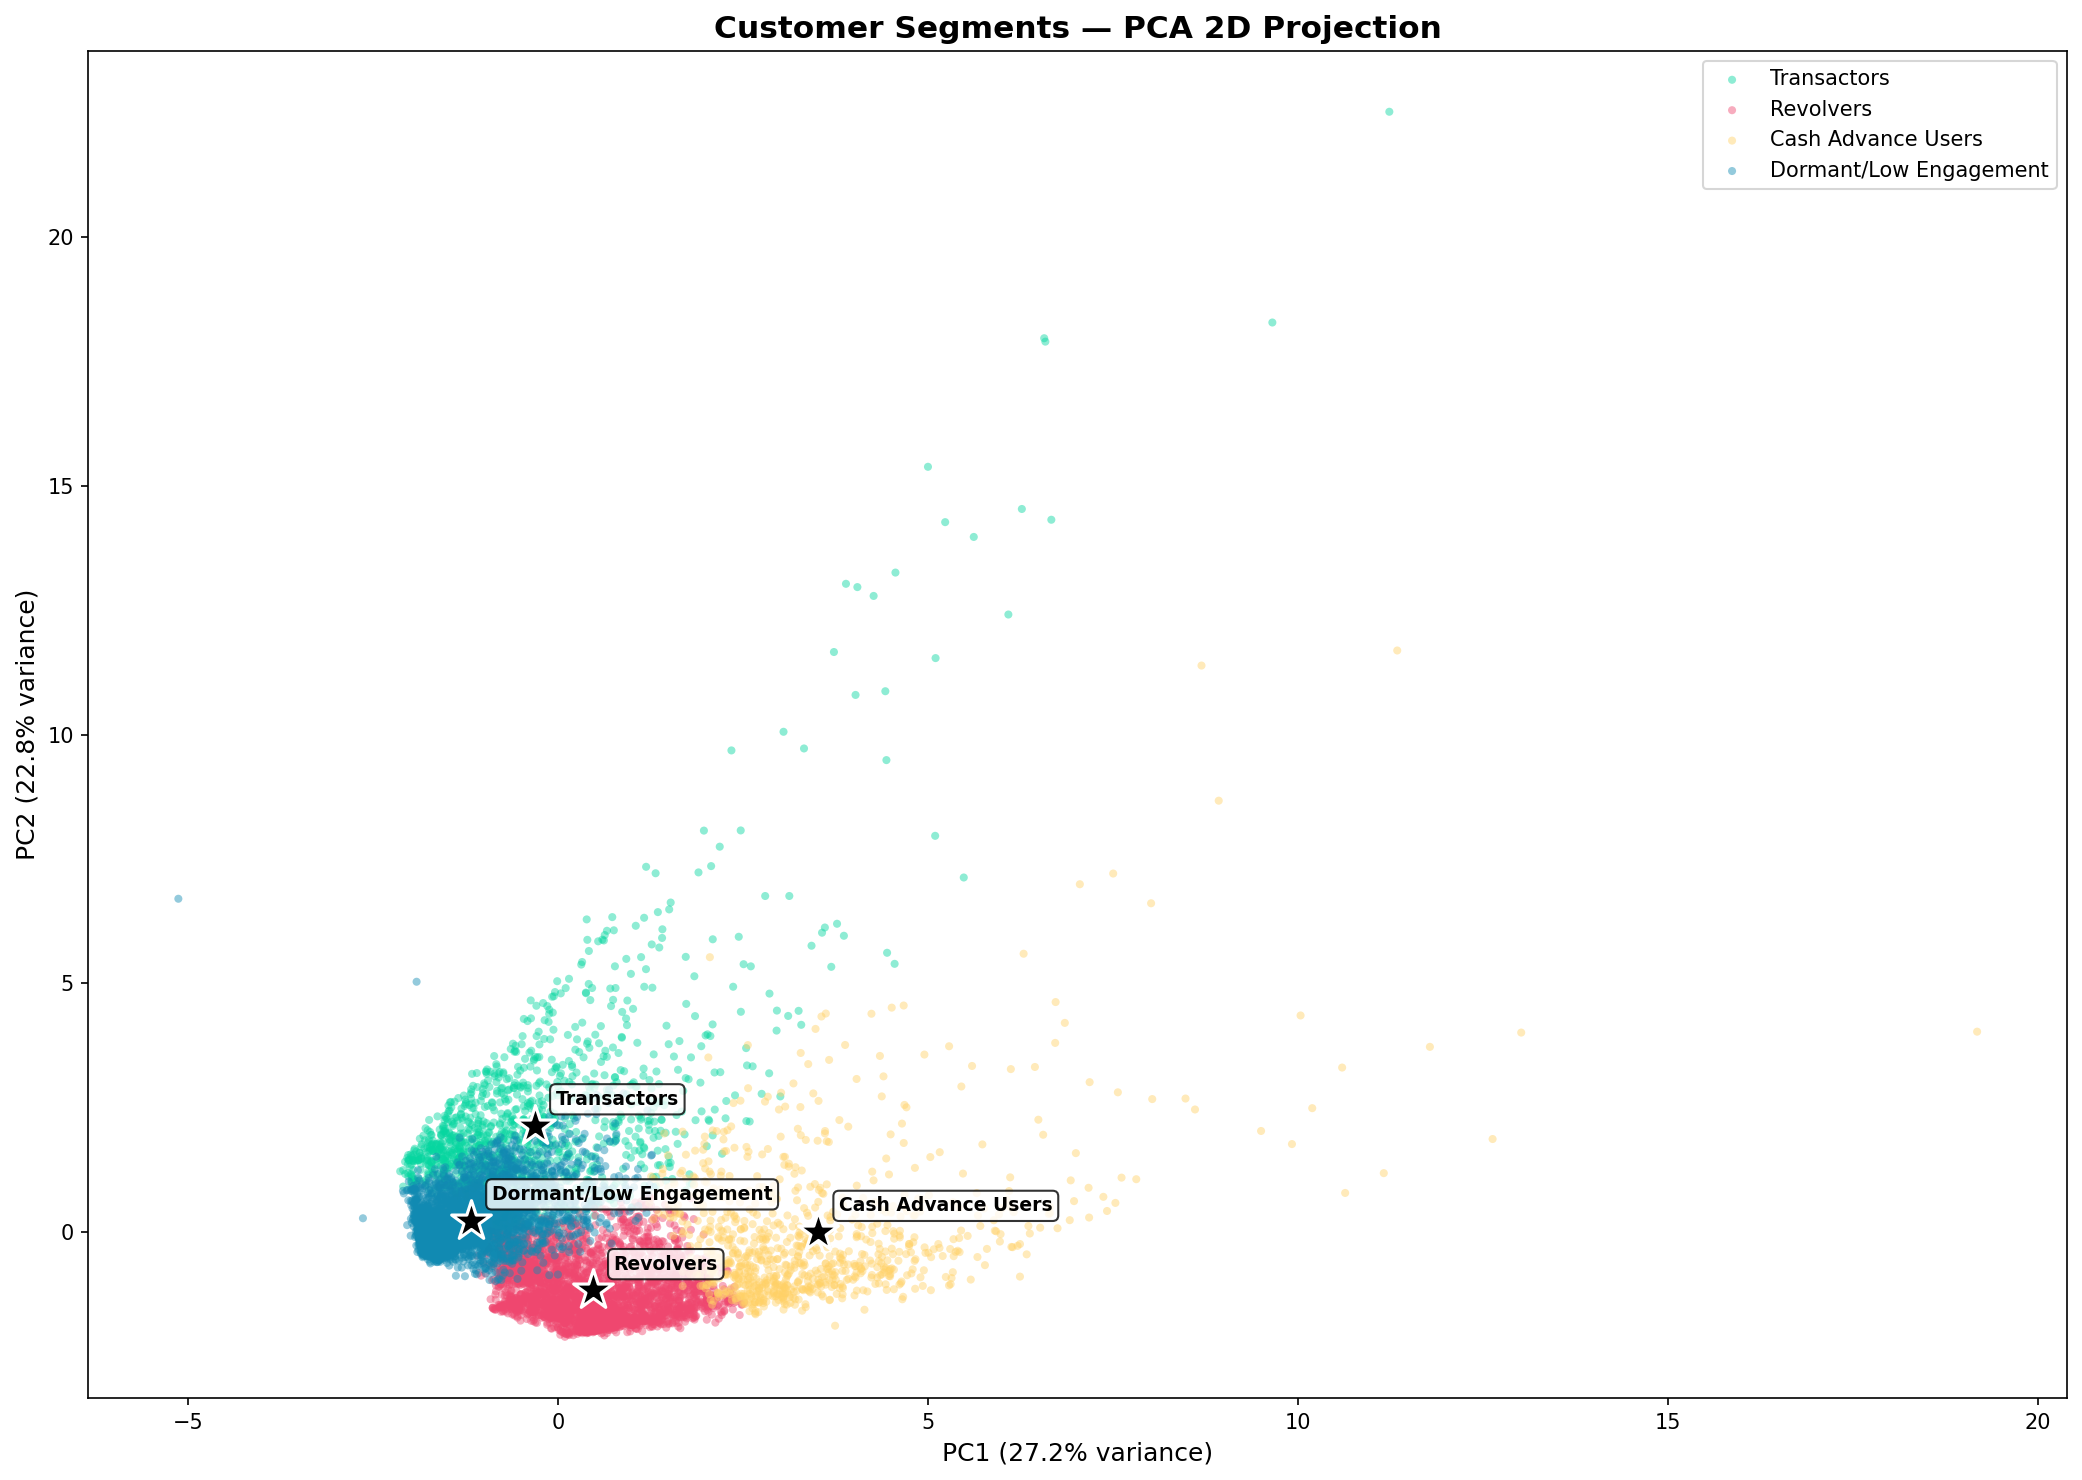

In [20]:
Image(filename=str(PLOTS_DIR / "07_pca_2d_scatter.png"), width=900)

## 8. Save Clustered Data for Anomaly Detection

Persist the dataframe (now including CLUSTER_ID, SEGMENT_NAME,
PC1, PC2) for use in Notebook 04.

In [21]:
from src.utils import PROCESSED_DATA_DIR

clustered_path = PROCESSED_DATA_DIR / "clustered_customers.csv"
df.to_csv(clustered_path, index=True)
print(f"  \u2713 Clustered data saved \u2192 {clustered_path.name}")

  ✓ Clustered data saved → clustered_customers.csv


## 9. Key Observations

- The **elbow** and **silhouette** plots both support k=4 as the
  optimal cluster count.
- In 2-D PCA space, the four segments form distinguishable
  clusters, though **Revolvers** and **Cash Advance Users** show
  some overlap along PC2.
- The first two principal components explain a significant portion
  of the total variance, validating PCA as an effective
  dimensionality reduction for this dataset.

---
*Next: [04_Anomaly_Detection.ipynb](04_Anomaly_Detection.ipynb) →
IQR/Z-score outlier flags and Isolation Forest scoring.*